# EDIFF.BGROUND :: Subtract background

* Version 2026-05-21
* [Jupyter](https://docs.jupyter.org/en/latest/) template,
  which shows how to subtract background when processing a 2D electron diffraction pattern.
    - The template extends the {background subtraction step} in the basic example (EX1.AU).
    - It starts with standard processing, shows all possible bkg methods, and finalizes the processing.
* The template should be self-explanatory, but may want to look at the following:
    * **[EDIFF website](https://pypi.org/project/ediff/)** at PyPI
      = brief description, installation, links to documentation and examples.
    * **[EDIFF documentation](https://mirekslouf.github.io/ediff/docs/pdoc.html/ediff.html)** at GitHub
      = complete online documentation of all functions in the package.
    * **Contextual help** in Jupyter/Spyder = set cursor to any function + press `Shift+Tab` (Jupyter) or `Ctrl+I` (Spyder).

## Start processing of 2D electron diffraction pattern

### 0. EDIFF :: Initialize

In [1]:
# Import of EDIFF package
import ediff as ed
import pywt
import numpy as np
# Set global plot parameters
ed.bkg.Plots.set_plot_params(size=(10,5), fontsize=8, dpi=120)
# Define input data
# (THEOR_STRUCTURE = theoretical/expected crystal structure
# (EXP_DIFFRACTOGRAM = experimental 2D electron diffraction pattern
THEOR_STRUCTURE = r'CIF/au_9008463.cif'
EXP_DIFFRACTOGRAM = r'DATA//au_sum_f_16bit.png'

### 1. XRD :: Calculate theoretical diffractogram

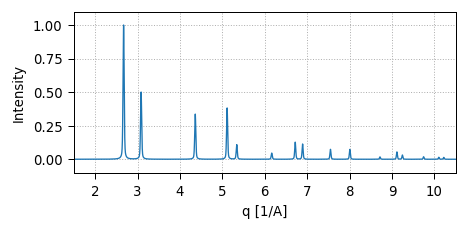

In [2]:
# Calculate theoretical 1D diffractogram/profile
XRD = ed.pcryst.XRD_polycrystal(
	description = 'Au,fcc :: theoretical diffraction pattern',
	structure = THEOR_STRUCTURE,
	wavelength = 0.71, two_theta_range = (5,100), peak_profile_sigma = 0.1)
# --- show the result = calculated/theroretical 1D XRD diffractogram
XRD.diffractogram.show('q', 'I',
    'q [1/A]', 'Intensity', (1.5,10.5), (-0.1, 1.1))

### 2. ELD :: Read experimental 2D diffractogram

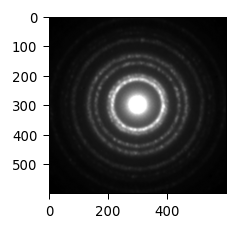

In [3]:
# Read 2D powder electron diffractogram 
ELD = ed.pcryst.ELD_polycrystal(
	description = 'Au :: 4D-STEM-PNBD pattern',
    diffractogram2D = EXP_DIFFRACTOGRAM)
# --- show the result = experimental 2D-diffractogram
ELD.diffractogram2D.show(icut=150)

### 3. ELD :: Find center of 2D diffracgogram

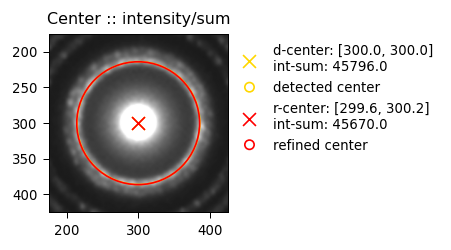

In [4]:
# Find center of the 2D diffractogram
ELD.find_center(detection='intensity', refinement='sum', icut=200, verbose=0)
# --- show the result = center of 2D diffractogram
ELD.center.show(csquare=250)

### 4. ELD :: Convert 2D diffractogram to 1D

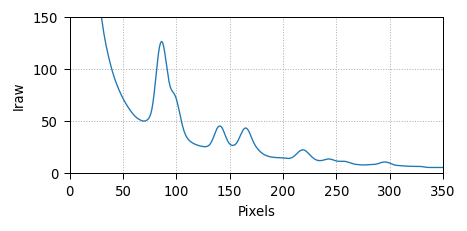

In [5]:
# Calculate 1D radial profile/diffractogram
ELD.calculate_1Ddiffractogram()
# --- show the result = 1D radially averaged profile
ELD.diffractogram.show('Pixels','Iraw', Xlim=350, Ylim=150)

## Intermediate step :: Test bkg subtraction methods

### M1 :: InteractivePlot
* Interactive plot semi-automated, requiring some input from the user.
* In Jupyter, the method is performed in four steps, corresponding to cells (a)-(d) below:
    - (a) Switch to interative plots
    - (b) Run the InteractivePlot method - follow the instructions to define bkg points
    - (c) Switch back to non-interactive plot
    - (d) Show the result

In [6]:
# (a) Switch to interactive plots
%matplotlib qt

In [7]:
# (b) Subtract background
#   - a new window will open
#   - follow the instructions to define the bkg points (keyboard: 1,2,..6)
#   - when done, save the results (keyboard: b,t,s) and close the plot window
ELD.subtract_background('InteractivePlot', bkg_file='SAVED.BKG/bkg_m1.txt',
    xlabel='Pixels', ylabel='Intensity', xlim=350, ylim=150);

(0) Click on the newly-opened window {Background correction},
    which is a Matplotlib interative figure with extra shortcuts.
(1) Use Matplotlib UI + keyboard shortcuts to define a background:
    1,2 = add/delete a background point close to the mouse cursor
    3,4,5,6 = show bkg points + linear/quadratic/cubic background
(2) Save the results + close the window when you are done:
    a,b = read/save background points from/to BKG-file
    s,t = save background data in PNG-file/TXT-file-and-object
(3) Detailed help, complete documentation, and worked examples:
    https://mirekslouf.github.io/bground/docs



In [8]:
# (c) Switch back to non-interactive plots
%matplotlib inline

In [9]:
# (d) Show the result = ELD diffractogram after bkg subtraction
ELD.diffractogram.show('Pixels','I', Xlim=350, Ylim=100, Ylabel='Intensity')

ValueError: Column 'I' does not exist!

In [10]:
# (e) Save result if needed
# (here: just for checking and completness
# (real use: the data in ELD object are saved at the end of processing
ELD.diffractogram.save('SAVED.BKG/bkg_m1_vfin.txt')

### M2 :: RestoreFromPoints

* *RestoreFromPoints* method is a supplement to the previous *InteractivePlot* method.
* It reads the previously saved background points (typically saved in txt.pb file) and re-subtract the background.
    - In real scenarios, it can be practical for repeated bkg subtractions.
    - In this model case, we will just copy the bkg file (a) and run the method (b).

In [15]:
# Copy the background points to new file
import shutil
shutil.copy('SAVED.BKG/bkg_m1.txt.bp', 'SAVED.BKG/bkg_m2.txt.bp');

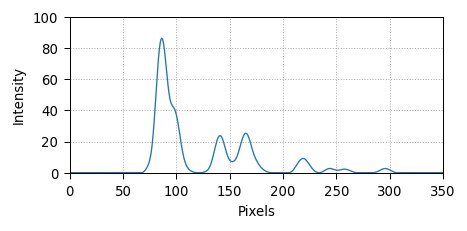

In [16]:
# Subtract background
ELD.subtract_background('RestoreFromPoints', bkg_file='SAVED.BKG/bkg_m2.txt',
    xlabel='Pixels', ylabel='Intensity', xlim=350, ylim=150);
# --- show the result
ELD.diffractogram.show('Pixels','I', Xlim=350, Ylim=100, Ylabel='Intensity')

In [17]:
# (e) Save result if needed
# (here: just for checking and completness
# (real use: the data in ELD object are saved at the end of processing
ELD.diffractogram.save('SAVED.BKG/bkg_m2_vfin.txt')

### M3 :: SimpleFunc

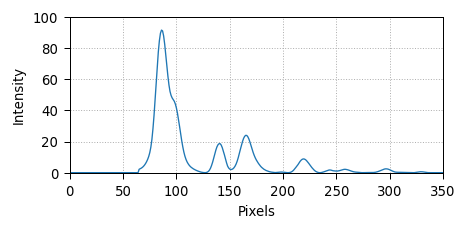

In [18]:
# Subtract background
ELD.subtract_background('SimpleFuncs', 
    algorithm='RollingBall', xrange=[65,350], radius=70,
    xlabel='Pixels', ylabel='Intensity', xlim=350, ylim=150)
# Show the result
ELD.diffractogram.show('Pixels','I', Xlim=350, Ylim=100, Ylabel='Intensity')

In [19]:
# Save result if needed
# (here: just for checking and completness
# (real use: the data in ELD object are saved at the end of processing
ELD.diffractogram.save('SAVED.BKG/bkg_m3_vfin.txt')

### M4 :: WaveletFunc

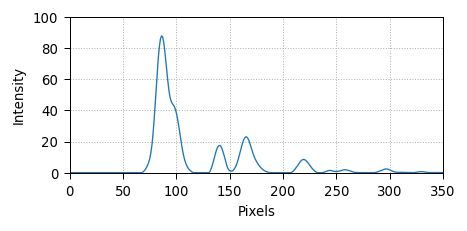

In [20]:
def wavelet_background_subtraction(intensity_1d, wavelet='sym4', level=6, max_iter=8):
    """
    Estimates the background of a 1D diffraction profile automatically
    utilizing an iterative Discrete Wavelet Transform (DWT).
    """
    signal = np.array(intensity_1d, dtype=float)
    background = np.copy(signal)
    
    for _ in range(max_iter):
        # Wavelet decomposition
        coeffs = pywt.wavedec(background, wavelet, level=level)
        
        # Reconstruction isolating only the approximation coefficient (low frequencies)
        bkg_reconstructed = pywt.waverec(coeffs[:1] + [None] * (len(coeffs) - 1), wavelet)
        bkg_reconstructed = bkg_reconstructed[:len(signal)]
        
        # Retain the minimum value to prevent intense peaks from biasing the baseline
        background = np.minimum(background, bkg_reconstructed)
        
    return background

# Extract experimental data using proper DataFrame indexing to prevent errors
# 'Pixels' and 'I' represent the immutable original column names
pixels = ELD.diffractogram['Pixels'].values
iraw = ELD.diffractogram['I'].values

# Compute the background automatically via mathematical decomposition
calculated_bkg = wavelet_background_subtraction(iraw, wavelet='sym4', level=6, max_iter=8)

# Subtract the estimated background from the raw intensity
i_corrected = iraw - calculated_bkg
i_corrected = np.clip(i_corrected, a_min=0, a_max=None)  # Excludes artificial negative values
distortion_threshold = 55
i_corrected[:distortion_threshold] = 0.0

# Update the intensity values directly within the original column structure
ELD.diffractogram['I'] = i_corrected

# Display the graphical output according to the established protocol parameters
ELD.diffractogram.show('Pixels', 'I', Xlim=350, Ylim=100, Ylabel='Intensity')

# Export the results to the corresponding sub-directory
ELD.diffractogram.save('SAVED.BKG/bkg_m4_wavelet.txt')

## Final step :: Finish the processing

### 5. ELD :: Subtract background

* We will take one of the above-tested bkg subtraction methods.
* Here: the simple *RestoreFromPoints* method - fast and reliable if the bkg was defined by *InteractivePlot* method.

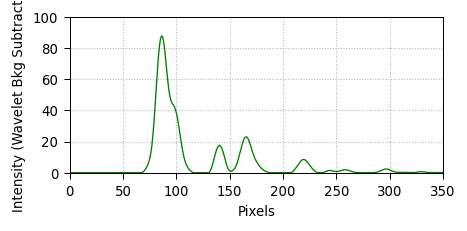

In [21]:
# 5. Display the graphical output according to the established protocol parameters
ELD.diffractogram.show('Pixels', 'I', Xlim=350, Ylim=100, Ylabel='Intensity (Wavelet Bkg Subtracted)', color='green')

### 6. ELD :: Calibrate

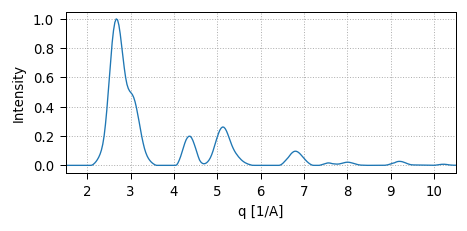

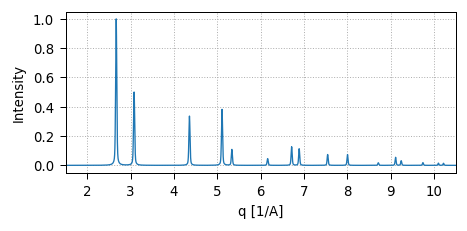

In [22]:
# ELD :: calibrate + normalize 1D diffractogram = Pixels->q + normalized I
# (this updates self.profile => ed.io.Diffractogram object (4 cols => 5 cols)
ELD.calibrate_and_normalize('MaxPeaks', XRD)
# ----- show the calibrated ELD diffractogram + corresponding XRD diffractogram 
ELD.diffractogram.show('q','I',
    Xlabel='q [1/A]', Ylabel='Intensity', Xlim=(1.5,10.5))
XRD.diffractogram.show('q','I',
    Xlabel='q [1/A]', Ylabel='Intensity', Xlim=(1.5,10.5))

### 7. ELD-XRD :: Final comparison and fine-tuning

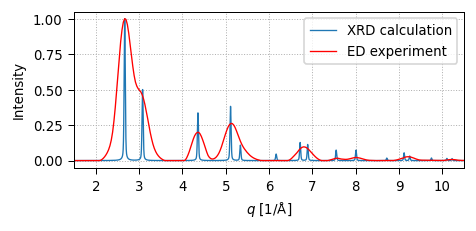

In [23]:
# ELD-XRD comparison
# (this fine-tunes the calibration and plots final comparison of ELD and XRD
ELD.compare_with_XRD(XRD, fine_tune=1.000, Xlim=(1.5,10.5), 
    out_file=r'RESULTS/1_eld-xrd_comparison.png', out_dpi=300)

### 8. ELD-XRD :: Save final results

In [24]:
# Finalization :: save final XRD and ELD diffractograms
# (this saves the final ELD and XRD data => for further processing/plotting
# (NOTE: *fine_tune* argument should be the same as in the previous cell!
XRD.diffractogram.save('RESULTS/2_xrd_diffractogram.txt')
ELD.diffractogram.save('RESULTS/3_eld_diffractogram.txt', fine_tune=1.000)

In [25]:
# END of program.
# The bkg subtraction testing results => SAVED.BKG subdir.
# The final processing of ELD diffractogram => RESULTS subdir.

In [1]:
import os
print(os.getcwd())

D:\GIT\X4_ADRIANA-PELAYO\EX4.BGROUND
